<a href="https://colab.research.google.com/github/Pedrogui29/TP547--Principios-de-Simulacao-de-Sistemas-de-Comunicacao/blob/main/TrabalhoMarkov/trabalho_markov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install numpy
!pip install matplotlib
!pip install networkx

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from numpy.linalg import matrix_power

# Matriz de transicao de estados do sensor IoT
# Estado 0: operacional | 1: pequena degradacao | 2: falha moderada | 3: modo critico | 4: queimado (absorvente)
P = np.array([
    [0.7, 0.3, 0.0, 0.0, 0.0],  # do estado 0
    [0.2, 0.5, 0.3, 0.0, 0.0],  # do estado 1
    [0.0, 0.1, 0.5, 0.4, 0.0],  # do estado 2
    [0.0, 0.0, 0.0, 0.6, 0.4],  # do estado 3
    [0.0, 0.0, 0.0, 0.0, 1.0],  # do estado 4 (absorvente)
])

estados = ['0', '1', '2', '3', '4']
n_estados = len(estados)
print('Matriz de transicao P:')
print(P)

Matriz de transicao P:
[[0.7 0.3 0.  0.  0. ]
 [0.2 0.5 0.3 0.  0. ]
 [0.  0.1 0.5 0.4 0. ]
 [0.  0.  0.  0.6 0.4]
 [0.  0.  0.  0.  1. ]]


In [10]:
# Simulacao da cadeia de Markov por Monte Carlo
n_sim = 100000  # numero de simulacoes
chain_length = 50  # numero de passos por simulacao
valor_inicial = 0  # sensor comeca operacional

# Simula uma unica trajetoria para visualizacao
np.random.seed(42)
trajetoria = np.zeros(chain_length, int)
trajetoria[0] = valor_inicial
for i in np.arange(1, chain_length):
    linha_atual = P[trajetoria[i - 1]]
    acumulada = np.cumsum(linha_atual)
    r = np.random.uniform(0, 1)
    trajetoria[i] = np.argmax(acumulada > r)

# Monte Carlo: estima probabilidades no passo 10
passo = 10
chain_mc = np.zeros(n_sim, int)
for j in np.arange(n_sim):
    chain = np.zeros(passo + 1, int)
    chain[0] = valor_inicial
    for i in np.arange(1, passo + 1):
        linha_atual = P[chain[i - 1]]
        acumulada = np.cumsum(linha_atual)
        r = np.random.uniform(0, 1)
        chain[i] = np.argmax(acumulada > r)
    chain_mc[j] = chain[passo]

print(f'Probabilidades no passo {passo} (Monte Carlo):')
for s in range(n_estados):
    print(f'  P(estado {s}) = {np.sum(chain_mc == s) / n_sim:.4f}')

Probabilidades no passo 10 (Monte Carlo):
  P(estado 0) = 0.1835
  P(estado 1) = 0.1729
  P(estado 2) = 0.1318
  P(estado 3) = 0.1558
  P(estado 4) = 0.3561


In [11]:
# Calculo analitico das probabilidades usando potencia da matriz
x0 = np.array([1.0, 0.0, 0.0, 0.0, 0.0])  # sensor inicia no estado 0
xn = np.dot(x0, matrix_power(P, passo))
print(f'Probabilidades no passo {passo} (analitico):')
for s in range(n_estados):
    print(f'  P(estado {s}) = {xn[s]:.4f}')

Probabilidades no passo 10 (analitico):
  P(estado 0) = 0.1833
  P(estado 1) = 0.1737
  P(estado 2) = 0.1310
  P(estado 3) = 0.1569
  P(estado 4) = 0.3551


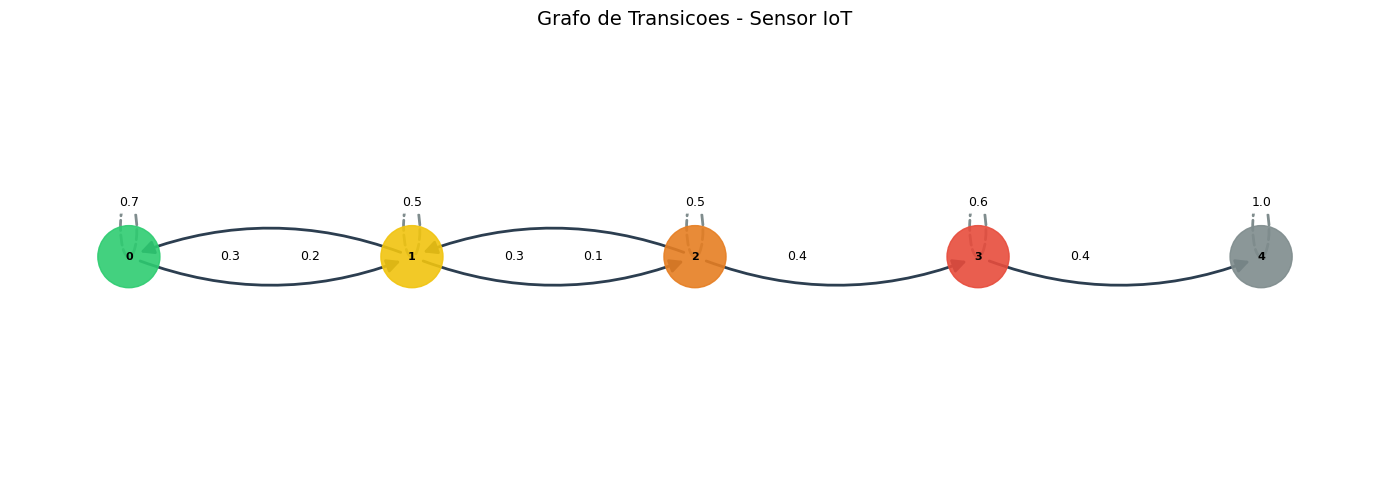

In [12]:
# Grafo de transicoes de estados
G = nx.DiGraph()
rotulos_nos = {i: estados[i] for i in range(n_estados)}
G.add_nodes_from(range(n_estados))

arestas = []
pesos = {}
for i in range(n_estados):
    for j in range(n_estados):
        if P[i, j] > 0:
            G.add_edge(i, j, weight=P[i, j])
            arestas.append((i, j))
            pesos[(i, j)] = f'{P[i, j]:.1f}'

pos = {
    0: (0, 0),
    1: (2, 0),
    2: (4, 0),
    3: (6, 0),
    4: (8, 0),
}

cores = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#7f8c8d']

plt.figure(figsize=(14, 5))
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color=cores, alpha=0.9)
nx.draw_networkx_labels(G, pos, labels=rotulos_nos, font_size=8, font_weight='bold')
nx.draw_networkx_edges(
    G, pos,
    edgelist=[(i, j) for i, j in arestas if i != j],
    arrows=True,
    arrowsize=20,
    width=2,
    connectionstyle='arc3,rad=0.2',
    edge_color='#2c3e50'
)
nx.draw_networkx_edges(
    G, pos,
    edgelist=[(i, i) for i in range(n_estados)],
    arrows=True,
    arrowsize=15,
    width=2,
    connectionstyle='arc3,rad=0.6',
    edge_color='#7f8c8d',
    style='dashed'
)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=pesos,
    font_size=9,
    label_pos=0.35
)
plt.title('Grafo de Transicoes - Sensor IoT', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

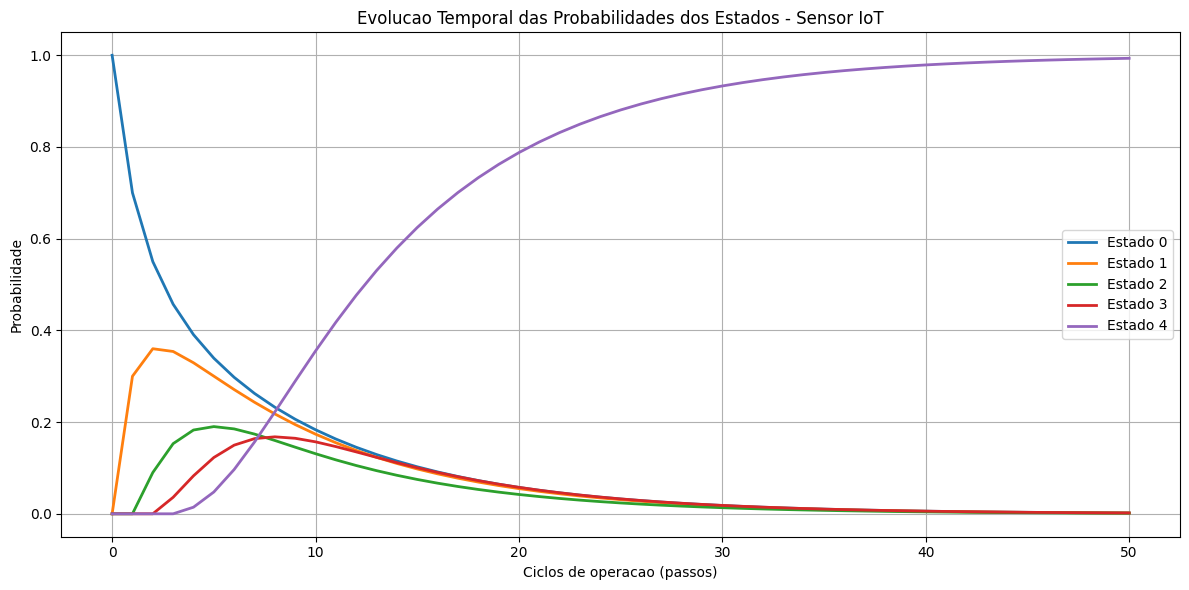

In [13]:
# Evolucao temporal das probabilidades dos estados
n_passos = 50
passos = np.arange(0, n_passos + 1)
prob_estados = np.zeros((n_passos + 1, n_estados))
prob_estados[0] = x0

for k in passos[1:]:
    prob_estados[k] = np.dot(x0, matrix_power(P, k))

plt.figure(figsize=(12, 6))
rotulos = ['Estado 0', 'Estado 1', 'Estado 2', 'Estado 3', 'Estado 4']
for s in range(n_estados):
    plt.plot(passos, prob_estados[:, s], label=rotulos[s], linewidth=2)

plt.xlabel('Ciclos de operacao (passos)')
plt.ylabel('Probabilidade')
plt.title('Evolucao Temporal das Probabilidades dos Estados - Sensor IoT')
plt.legend(loc='center right')
plt.grid(True)
plt.tight_layout()
plt.show()

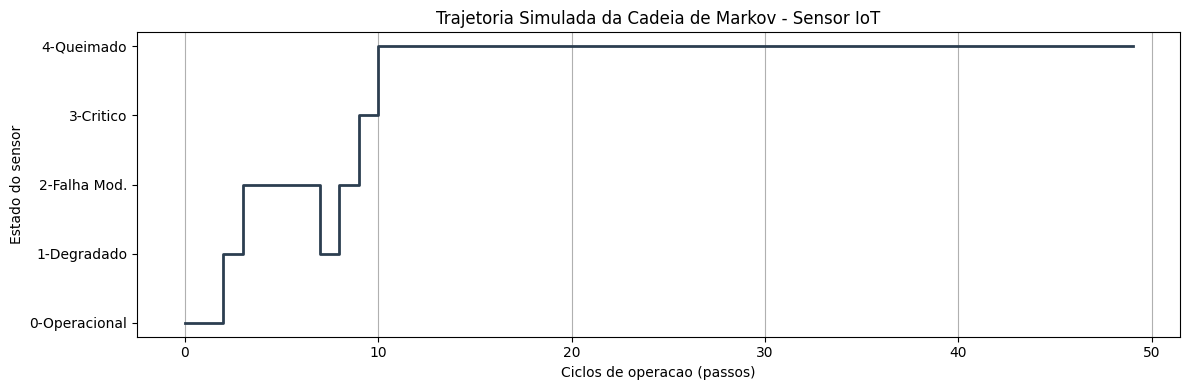

In [14]:
# Visualizacao da trajetoria simulada
plt.figure(figsize=(12, 4))
plt.step(np.arange(chain_length), trajetoria, where='post', linewidth=2, color='#2c3e50')
plt.yticks(range(n_estados), ['0-Operacional', '1-Degradado', '2-Falha Mod.', '3-Critico', '4-Queimado'])
plt.xlabel('Ciclos de operacao (passos)')
plt.ylabel('Estado do sensor')
plt.title('Trajetoria Simulada da Cadeia de Markov - Sensor IoT')
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()